In [1]:
from pathlib import Path
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from dotenv import load_dotenv
from pyspark.ml.linalg import SparseVector, VectorUDT
from pyspark.ml.regression import LinearRegression
from pyspark import StorageLevel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

load_dotenv()

True

In [2]:
spark = (
    SparkSession.builder
    .appName("uk-property-flip-detector")
    .config("spark.jars", "jars/postgresql-jdbc.jar")
    .config("spark.driver.memory", "6g")
    .getOrCreate()
)

26/09/24 17:21:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


In [3]:
BASE_YEAR = 1995

df = (
    spark.read
    .format("jdbc")
    .option("url", "jdbc:postgresql://192.168.0.204:5432/land_registry")
    .option("dbtable", "repeat_sale_pairs_regression")
    .option("user", os.environ["PGUSER"])
    .option("password", os.environ["PGPASSWORD"])
    .option("driver", "org.postgresql.Driver")
    .option("partitionColumn", "property_id")
    .option("lowerBound", "1")
    .option("upperBound", "15184630")
    .option("numPartitions", "8")
    .load()
)

pairs = (
    df
    .withColumn(
        # month index - diff in months from base + months elapsed from last
        "prev_period",
        (F.year("prev_date_of_transfer") - BASE_YEAR) * 12
        + (F.month("prev_date_of_transfer") - 1),
    )
    .withColumn(
        "curr_period",
        (F.year("curr_date_of_transfer") - BASE_YEAR) * 12
        + (F.month("curr_date_of_transfer") - 1),
    )
    # cast decimal as double
    .withColumn("log_price_ratio", F.col("log_price_ratio").cast("double"))
)


pairs.select(
    "prev_date_of_transfer", "prev_period",
    "curr_date_of_transfer", "curr_period",
).show(10)

+---------------------+-----------+---------------------+-----------+
|prev_date_of_transfer|prev_period|curr_date_of_transfer|curr_period|
+---------------------+-----------+---------------------+-----------+
|           2003-06-12|        101|           2018-05-18|        280|
|           1998-03-06|         38|           2006-05-18|        136|
|           1996-03-25|         14|           2022-10-06|        333|
|           1998-12-10|         47|           2001-06-29|         77|
|           2001-06-29|         77|           2007-03-23|        146|
|           2007-10-09|        153|           2013-03-28|        218|
|           2013-03-28|        218|           2018-02-16|        277|
|           2003-10-21|        105|           2008-07-17|        162|
|           2004-04-02|        111|           2023-05-26|        340|
|           1999-11-26|         58|           2003-12-11|        107|
+---------------------+-----------+---------------------+-----------+
only showing top 10 

### Parallel JDBC read

Parallelism isn't strictly needed at this scale (12.4M rows fits comfortably on one machine), but the read is partitioned to demonstrate how it would scale.

Spark splis range into 8 slices and sends 8 queries to Postgres, one per partition, each of the form:

    SELECT <columns> FROM repeat_sale_pairs_regression
    WHERE property_id >= X AND property_id < Y

Each executor thread reads its slice concurrently. The bounds only control how the range is divided; they don't filter rows.

`.explain(True)` demonstrates the optimisations done by the Catalyst Optimiser when calling select on the two cols.

In [4]:
pairs.select("prev_period", "curr_period").explain(True)

== Parsed Logical Plan ==
'Project ['prev_period, 'curr_period]
+- Project [property_id#0L, prev_transaction_id#1, curr_transaction_id#2, prev_date_of_transfer#3, curr_date_of_transfer#4, prev_price#5, curr_price#6, prev_ppd_category#7, curr_ppd_category#8, prev_duration#9, curr_duration#10, holding_period_days#11, cast(log_price_ratio#12 as double) AS log_price_ratio#15, prev_period#13, curr_period#14]
   +- Project [property_id#0L, prev_transaction_id#1, curr_transaction_id#2, prev_date_of_transfer#3, curr_date_of_transfer#4, prev_price#5, curr_price#6, prev_ppd_category#7, curr_ppd_category#8, prev_duration#9, curr_duration#10, holding_period_days#11, log_price_ratio#12, prev_period#13, (((year(curr_date_of_transfer#4) - 1995) * 12) + (month(curr_date_of_transfer#4) - 1)) AS curr_period#14]
      +- Project [property_id#0L, prev_transaction_id#1, curr_transaction_id#2, prev_date_of_transfer#3, curr_date_of_transfer#4, prev_price#5, curr_price#6, prev_ppd_category#7, curr_ppd_categor

In [5]:
# period index validation
pairs.select(
    F.min("prev_period"), F.max("prev_period"),
    F.min("curr_period"), F.max("curr_period"),
).show()

print("backwards:", pairs.filter(F.col("curr_period") < F.col("prev_period")).count())
print("same month:", pairs.filter(F.col("curr_period") == F.col("prev_period")).count())

+----------------+----------------+----------------+----------------+
|min(prev_period)|max(prev_period)|min(curr_period)|max(curr_period)|
+----------------+----------------+----------------+----------------+
|               0|             377|               0|             378|
+----------------+----------------+----------------+----------------+



backwards: 0


same month: 12278


Trimming and filtering: drops July 2026 (incomplete registrations) and same-month pairs (zero rows in the design matrix); keeps only regression columns before caching.

In [6]:
MAX_PERIOD = 377  # July 2026 (378) trimmed: incomplete due to registration lag

pairs_clean = (
    pairs
    .filter(F.col("curr_period") <= MAX_PERIOD)
    .filter(F.col("curr_period") != F.col("prev_period"))
    .select("property_id", "prev_period", "curr_period", "log_price_ratio")
    .cache()
)

print("pairs after filtering:", pairs_clean.count())

print("overlap:", pairs.filter(
    (F.col("curr_period") == 378) & (F.col("curr_period") == F.col("prev_period"))
).count())

pairs after filtering: 12407196


overlap: 0


In [7]:
pairs_clean.count()

12407196

In [8]:
N_PARAMS = MAX_PERIOD

# user defined function declaring return type to be VectorUDT from ml.linalg
# Apache Arrow turned off due to incompatibility with user defined types
@F.udf(returnType=VectorUDT(), useArrow=False)
def bmn_vector(prev_p, curr_p):
    entries = {}
    if prev_p > 0:
        entries[prev_p - 1] = -1.0
    if curr_p > 0:
        entries[curr_p - 1] = 1.0
    return SparseVector(N_PARAMS, entries)

reg_input = (
    pairs_clean
    .withColumn("features", bmn_vector("prev_period", "curr_period"))
    .withColumn("interval", (F.col("curr_period") - F.col("prev_period")).cast("double"))
    .select("features", F.col("log_price_ratio").alias("y"), "interval")
    .persist(StorageLevel.MEMORY_AND_DISK)
)
reg_input.count()  # materialises the cache; expect 12,407,196

lr = LinearRegression(
    featuresCol="features",
    labelCol="y",
    fitIntercept=False,
    solver="normal",
    regParam=0.0,
    standardization=False,
)
model = lr.fit(reg_input)

26/09/24 17:26:25 WARN Instrumentation: [a63b7e6f] regParam is zero, which might cause numerical instability and overfitting.
netlib-blas: JNI_OnLoad: dlopen(libblas.so.3) failed: libblas.so.3: cannot open shared object file: No such file or directory
netlib-lapack: JNI_OnLoad: dlopen(liblapack.so.3) failed: liblapack.so.3: cannot open shared object file: No such file or directory


In [9]:
beta = np.concatenate([[0.0], model.coefficients.toArray()])
index = 100 * np.exp(beta)
dates = pd.date_range("1995-01-01", periods=len(index), freq="MS")
bmn = pd.Series(index, index=dates, name="BMN index")

print(len(index))     # 378: periods 0..377
print(index[:13])     # 1995 through Jan 1996
print(index[-1])      # June 2026 
print(model.summary.r2, model.summary.rootMeanSquaredError)

378
[100.         101.06009691 101.78980376 101.59365994 102.21703866
 102.88368575 101.86406227 101.2055474  102.03102361 101.26579288
 101.80997466 102.82914173  99.18225737]
553.6074872108057
0.8090433316714255 0.2707552391357673


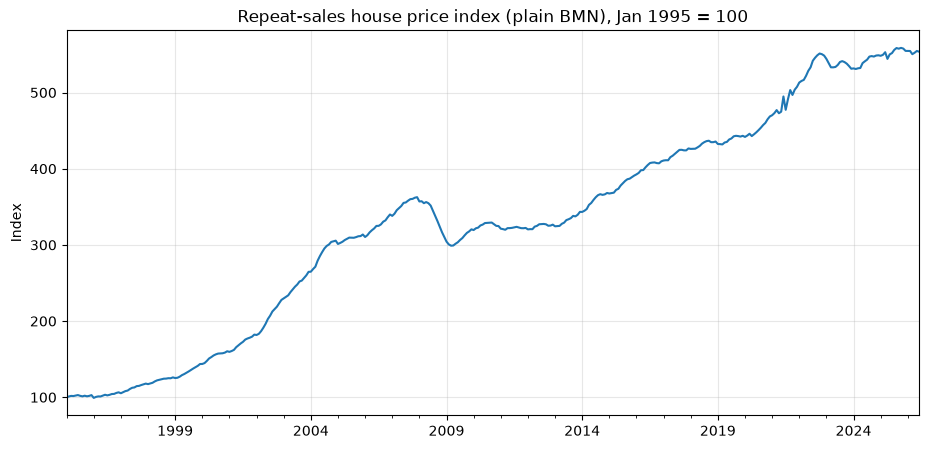

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
bmn.plot(ax=ax)
ax.set_title("Repeat-sales house price index (plain BMN), Jan 1995 = 100")
ax.set_ylabel("Index")
ax.grid(alpha=0.3)
plt.show()

In [11]:
resid = (
    model.transform(reg_input)
    .withColumn("e2", (F.col("y") - F.col("prediction")) ** 2)
)

s = resid.agg(
    F.covar_samp("interval", "e2").alias("cov"),
    F.var_samp("interval").alias("var"),
    F.avg("interval").alias("mean_x"),
    F.avg("e2").alias("mean_e2"),
).first()

b = s["cov"] / s["var"]
a = s["mean_e2"] - b * s["mean_x"]
print(f"a = {a:.5f}, b = {b:.6f}")

a = 0.06089, b = 0.000140


In [12]:
weighted = reg_input.withColumn(
    "w", 1.0 / (F.lit(a) + F.lit(b) * F.col("interval"))
)

lr_cs = LinearRegression(
    featuresCol="features",
    labelCol="y",
    weightCol="w",
    fitIntercept=False,
    solver="normal",
    regParam=0.0,
    standardization=False,
)
model_cs = lr_cs.fit(weighted)

beta_cs = np.concatenate([[0.0], model_cs.coefficients.toArray()])
index_cs = 100 * np.exp(beta_cs)
bmn_cs = pd.Series(index_cs, index=dates, name="Case-Shiller index")
print(index_cs[-1])

26/09/24 17:26:36 WARN Instrumentation: [d3bd3514] regParam is zero, which might cause numerical instability and overfitting.


561.5589419354393


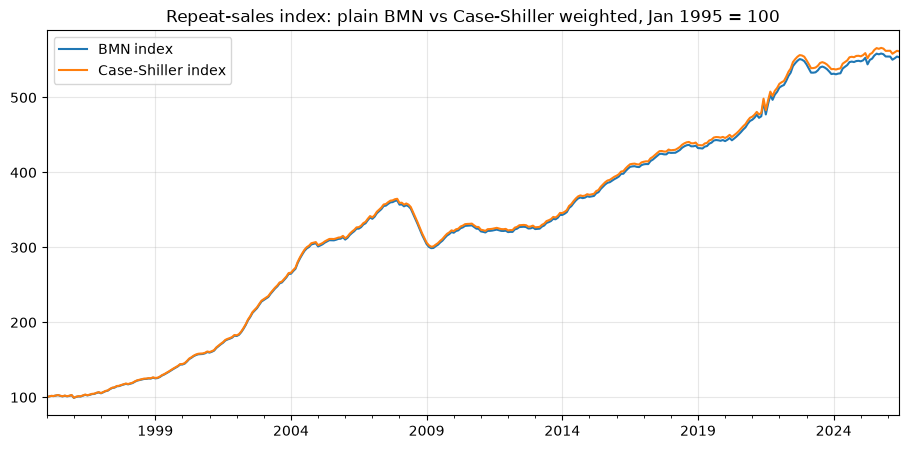

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
bmn.plot(ax=ax)
bmn_cs.plot(ax=ax)
ax.set_title("Repeat-sales index: plain BMN vs Case-Shiller weighted, Jan 1995 = 100")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [14]:
(
    resid
    .withColumn("years", F.floor(F.col("interval") / 12))
    .groupBy("years")
    .agg(F.avg("e2").alias("mean_e2"), F.count("*").alias("n"))
    .orderBy("years")
    .show(35)
)

+-----+-------------------+-------+
|years|            mean_e2|      n|
+-----+-------------------+-------+
|    0|   0.11193934742451| 602417|
|    1|0.07017196185871084|1071137|
|    2|0.05712879289256739|1308356|
|    3|0.06008460052133568|1296453|
|    4|0.06252305636620294|1177688|
|    5|  0.065797357005193|1010327|
|    6|0.06768837223946479| 850970|
|    7|0.06792753951514573| 727848|
|    8|0.06954288047309685| 610854|
|    9|0.07084642399649588| 523187|
|   10|0.07405119229856426| 454046|
|   11|0.07615545423506674| 387354|
|   12|0.07897697177790149| 326754|
|   13|0.08095871462692611| 288158|
|   14|0.08390936886032468| 263760|
|   15|0.08784386319761908| 235098|
|   16|0.09126954627340583| 208151|
|   17|0.09639831365331444| 189185|
|   18|0.09974628273304055| 168654|
|   19|0.10534614257953408| 143027|
|   20|0.10671048783738979| 117909|
|   21| 0.1073859819485706| 100278|
|   22|0.10955673745103808|  83580|
|   23|0.11391749288953933|  69012|
|   24|0.11393130014160993| 

In [15]:
def fit_bmn(df, weight_col=None):
    params = dict(featuresCol="features", labelCol="y", fitIntercept=False,
                  solver="normal", regParam=0.0, standardization=False)
    if weight_col:
        params["weightCol"] = weight_col
    return LinearRegression(**params).fit(df)

def to_index(model, name):
    beta = np.concatenate([[0.0], model.coefficients.toArray()])
    return pd.Series(100 * np.exp(beta), index=dates, name=name)

MIN_INTERVAL = 24  # months
reg_long = reg_input.filter(F.col("interval") >= MIN_INTERVAL)

# stage 1
m1 = fit_bmn(reg_long)

# stage 2
r = m1.transform(reg_long).withColumn("e2", (F.col("y") - F.col("prediction")) ** 2)
s = r.agg(F.covar_samp("interval", "e2").alias("cov"), F.var_samp("interval").alias("var"),
          F.avg("interval").alias("mx"), F.avg("e2").alias("mz")).first()
b2 = s["cov"] / s["var"]
a2 = s["mz"] - b2 * s["mx"]
print(f"a = {a2:.5f}, b = {b2:.6f}")

# stage 3
m3 = fit_bmn(reg_long.withColumn("w", 1.0 / (F.lit(a2) + F.lit(b2) * F.col("interval"))), "w")
bmn_cs_long = to_index(m3, "Case-Shiller, holds ≥ 2y")
print(bmn_cs_long.iloc[-1])

26/09/24 17:26:45 WARN Instrumentation: [9816bf5d] regParam is zero, which might cause numerical instability and overfitting.


a = 0.05040, b = 0.000210


26/09/24 17:26:53 WARN Instrumentation: [803d6369] regParam is zero, which might cause numerical instability and overfitting.


549.718801151304


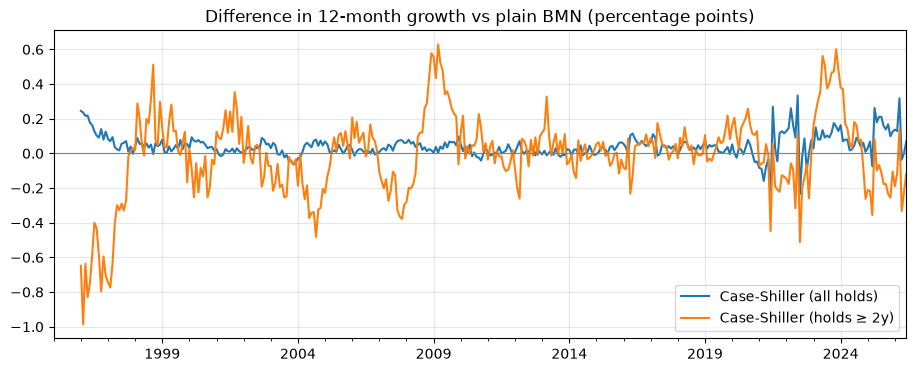

In [16]:
g = lambda s: 100 * (s / s.shift(12) - 1)

fig, ax = plt.subplots(figsize=(11, 4))
(g(bmn_cs) - g(bmn)).plot(ax=ax, label="Case-Shiller (all holds)")
(g(bmn_cs_long) - g(bmn)).plot(ax=ax, label=f"Case-Shiller (holds ≥ {MIN_INTERVAL // 12}y)")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("Difference in 12-month growth vs plain BMN (percentage points)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [17]:
def save_index(series, out_dir, filename):
    return series.rename_axis("month").to_frame().to_csv(out_dir / f"{filename}")

out = Path("data/processed")
out.mkdir(parents=True, exist_ok=True)

save_index(bmn, out, "bmn_index_plain.csv")
save_index(bmn_cs, out, "bmn_index_case_shiller.csv")
save_index(bmn_cs_long, out, f"bmn_index_case_shiller_min{MIN_INTERVAL}m.csv")
reg_input.unpersist()

DataFrame[features: vector, y: double, interval: double]